# Random Forest metadata model

Binary classification using patient metadata.

Current hypothesis:
- H1: biopsy recommendation
- H2: malignancy among biopsied lesions

Model selection is performed exclusively on the training set using patient-grouped cross-validation.

Random Forest is invariant to the scale of the predictors and to monotonic transformations, so no standardization is applied to the features.

## 1. Imports and configuration 

In [2]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------


import numpy as np
import pandas as pd

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedGroupKFold,
)

from sklearn.metrics import (
    auc,
    make_scorer,
    precision_recall_curve,
)

from sklearn.ensemble import RandomForestClassifier

from skin_lesion_ai.inference.evaluation import (
    evaluate,
    save_model,
)
from skin_lesion_ai.utils.data_utils import load_metadata_parquet


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

HYPOTHESIS = 1

RANDOM_STATE = 42
N_CV_SPLITS = 5

HYPOTHESIS_CONFIG = {
    1: {
        "target": "target_biopsy",
        "split_suffix": "h1",
        "description": "Biopsy recommendation",
    },
    2: {
        "target": "target_malignant",
        "split_suffix": "h2",
        "description": "Malignancy among biopsied lesions",
    },
}

if HYPOTHESIS not in HYPOTHESIS_CONFIG:
    raise ValueError("HYPOTHESIS must be either 1 or 2.")

TARGET = HYPOTHESIS_CONFIG[HYPOTHESIS]["target"]
SPLIT_SUFFIX = HYPOTHESIS_CONFIG[HYPOTHESIS]["split_suffix"]
HYPOTHESIS_DESCRIPTION = HYPOTHESIS_CONFIG[HYPOTHESIS]["description"]

MODEL_NAME = f"random_forest_metadata_h{HYPOTHESIS}"

print(f"Hypothesis {HYPOTHESIS}: {HYPOTHESIS_DESCRIPTION}")
print(f"Target: {TARGET}")
print(f"Model name: {MODEL_NAME}")

Hypothesis 1: Biopsy recommendation
Target: target_biopsy
Model name: random_forest_metadata_h1


## 2. Load train, validation and test splits 

In [3]:
df_train = load_metadata_parquet(
    stage="processed",
    filename=f"train_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_validation = load_metadata_parquet(
    stage="processed",
    filename=f"val_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_test = load_metadata_parquet(
    stage="processed",
    filename=f"test_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)


split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "lesions": [
            len(df_train),
            len(df_validation),
            len(df_test),
        ],
        "patients": [
            df_train["patient_id"].nunique(),
            df_validation["patient_id"].nunique(),
            df_test["patient_id"].nunique(),
        ],
        "positive_rate": [
            df_train[TARGET].mean(),
            df_validation[TARGET].mean(),
            df_test[TARGET].mean(),
        ],
    }
)

display(split_summary)

,split,lesions,patients,positive_rate
0,train,305024,784,0.002662
1,validation,38131,94,0.002649
2,test,38125,99,0.002623


## 3. Define predictors and target

The model uses four clinical metadata predictors:

- sex
- age
- anatomical site
- lesion diameter

Categorical variables use the encodings generated during preprocessing.
Anatomical site is represented through one-hot encoded columns rather than the integer code, avoiding the introduction of an artificial ordinal relationship.

In [4]:
FEATURES = [
    "sex_male",
    "age_approx",
    "anatom_site__anterior_torso",
    "anatom_site__head_neck",
    "anatom_site__lower_extremity",
    "anatom_site__posterior_torso",
    "anatom_site__upper_extremity",
    "clin_size_long_diam_mm",
]

ID_COLUMN = "isic_id"
GROUP_COLUMN = "patient_id"


required_columns = {
    ID_COLUMN,
    GROUP_COLUMN,
    TARGET,
    *FEATURES,
}

for split_name, df_split in {
    "train": df_train,
    "validation": df_validation,
    "test": df_test,
}.items():
    missing_columns = required_columns.difference(df_split.columns)

    if missing_columns:
        raise KeyError(
            f"{split_name} is missing required columns: {sorted(missing_columns)}"
        )

    if df_split[FEATURES].isna().any().any():
        raise ValueError(f"Missing predictor values found in {split_name}.")

print(f"Number of model columns: {len(FEATURES)}")
print("Predictors:")
for feature in FEATURES:
    print(f"- {feature}")

Number of model columns: 8
Predictors:
- sex_male
- age_approx
- anatom_site__anterior_torso
- anatom_site__head_neck
- anatom_site__lower_extremity
- anatom_site__posterior_torso
- anatom_site__upper_extremity
- clin_size_long_diam_mm


## 4. Prepare modelling matrices

Predictor matrices and target vectors are created for each split.

Patient identifiers are additionally retained as grouping labels for the cross-validation procedure. This allows `StratifiedGroupKFold` to preserve patient independence within the training set and prevents lesions from the same
patient from appearing in both training and validation folds.

In [5]:
# Training data
X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET].astype(int).copy()
groups_train = df_train[GROUP_COLUMN].copy()

# Validation data
X_validation = df_validation[FEATURES].copy()
y_validation = df_validation[TARGET].astype(int).copy()

# Test data
X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET].astype(int).copy()


print("Training:")
print(f"  X: {X_train.shape}")
print(f"  y: {y_train.shape}")
print(f"  patients: {groups_train.nunique():,}")

print("\nValidation:")
print(f"  X: {X_validation.shape}")
print(f"  y: {y_validation.shape}")

print("\nTest:")
print(f"  X: {X_test.shape}")
print(f"  y: {y_test.shape}")

Training:
  X: (305024, 8)
  y: (305024,)
  patients: 784

Validation:
  X: (38131, 8)
  y: (38131,)

Test:
  X: (38125, 8)
  y: (38125,)


## 5. Cross-validation and scoring strategy

Hyperparameter optimization is performed exclusively within the training set.

Because multiple lesions may belong to the same patient, standard stratified cross-validation would introduce patient-level leakage between folds.
Therefore, a `StratifiedGroupKFold` strategy is used, preserving class balance as far as possible while ensuring that all lesions from the same patient remain within the same fold.

The same five folds are precomputed and reused throughout all hyperparameter search stages to ensure a fair comparison between candidate models.

Candidate models are evaluated using three threshold-independent metrics:

1. **PR-AUC**, used as the primary selection criterion because of the strong class imbalance.
2. **ROC-AUC**, used as the first tie-breaker.
3. **Brier score**, used as the second tie-breaker to favor better-calibrated probability estimates.

PR-AUC is computed as the trapezoidal area under the Precision-Recall curve, using the same definition as the final evaluation pipeline.

No classification threshold is selected during cross-validation. Clinical threshold selection is performed later and exclusively on the validation set.

In [6]:
# ---------------------------------------------------------------------
# Cross-validation
# ---------------------------------------------------------------------

cv = StratifiedGroupKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Precompute folds so that exactly the same splits are reused during all hyperparameter search stages.
cv_splits = list(
    cv.split(
        X=X_train,
        y=y_train,
        groups=groups_train,
    )
)


# ---------------------------------------------------------------------
# Validate CV folds
# ---------------------------------------------------------------------

cv_summary = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    train_patients = set(groups_train.iloc[train_idx])
    val_patients = set(groups_train.iloc[val_idx])

    if train_patients.intersection(val_patients):
        raise ValueError(f"Patient leakage detected in CV fold {fold}.")

    cv_summary.append(
        {
            "fold": fold,
            "train_lesions": len(train_idx),
            "validation_lesions": len(val_idx),
            "train_patients": len(train_patients),
            "validation_patients": len(val_patients),
            "train_positive_rate": y_train.iloc[train_idx].mean(),
            "validation_positive_rate": y_train.iloc[val_idx].mean(),
        }
    )

cv_summary = pd.DataFrame(cv_summary)

display(cv_summary)

,fold,train_lesions,validation_lesions,train_patients,validation_patients,train_positive_rate,validation_positive_rate
0,1,244020,61004,628,156,0.002668,0.002639
1,2,244021,61003,628,156,0.002668,0.002639
2,3,244014,61010,627,157,0.002639,0.002754
3,4,244020,61004,626,158,0.002668,0.002639
4,5,244021,61003,627,157,0.002668,0.002639


In [7]:
# ---------------------------------------------------------------------
# Scoring functions
# ---------------------------------------------------------------------


def trapezoidal_pr_auc(y_true, y_prob):
    """Compute trapezoidal area under the Precision-Recall curve."""
    precision, recall, _ = precision_recall_curve(
        y_true,
        y_prob,
    )

    return auc(recall, precision)


pr_auc_scorer = make_scorer(
    trapezoidal_pr_auc,
    response_method="predict_proba",
)


SCORING = {
    "pr_auc": pr_auc_scorer,
    "roc_auc": "roc_auc",
    "brier": "neg_brier_score",
}


def select_best_candidate(cv_results):
    """Select the best candidate using PR-AUC > ROC-AUC > Brier score.

    A constant / non-discriminating classifier receives a misleadingly high
    trapezoidal PR-AUC of about (1 + prevalence) / 2, which can outrank
    genuinely useful models. The risk is acute for H1, whose positive
    prevalence is well below 1%. Candidates whose mean cross-validated
    ROC-AUC is not above 0.5 are therefore dropped before applying the
    ranking hierarchy. If every candidate is degenerate, the filter is
    skipped so a model is still returned.
    """

    results = pd.DataFrame(cv_results)

    discriminating_results = results[results["mean_test_roc_auc"] > 0.5]

    if not discriminating_results.empty:
        results = discriminating_results

    ranked_results = results.sort_values(
        by=[
            "mean_test_pr_auc",
            "mean_test_roc_auc",
            "mean_test_brier",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        na_position="last",
    )

    return int(ranked_results.index[0])

## 6. Broad hyperparameter search

A broad randomized search is first performed to explore the main dimensions controlling Random Forest capacity, tree structure and class imbalance.

The search explores:

- number of trees (`n_estimators`);
- maximum tree depth (`max_depth`);
- minimum samples required to split a node and to form a leaf (`min_samples_split`, `min_samples_leaf`);
- number of candidate features considered at each split (`max_features`);
- whether bootstrap sampling is used (`bootstrap`);
- class weighting (`class_weight`).

The best region identified in this stage is subsequently explored using a smaller exhaustive grid.

In [8]:
# ---------------------------------------------------------------------
# Class imbalance
# ---------------------------------------------------------------------

n_negative = int((y_train == 0).sum())
n_positive = int((y_train == 1).sum())

class_ratio = n_negative / n_positive

class_weight_values = [
    "balanced_subsample",
    {0: 1, 1: round(np.sqrt(class_ratio), 4)},
    #{0: 1, 1: round(class_ratio, 4)},
]

print(f"Negative lesions: {n_negative:,}")
print(f"Positive lesions: {n_positive:,}")
print(f"Negative / positive ratio: {class_ratio:.3f}")
print("class_weight candidates:")

for value in class_weight_values:
    print(f"- {value}")

Negative lesions: 304,212
Positive lesions: 812
Negative / positive ratio: 374.645
class_weight candidates:
- balanced_subsample
- {0: 1, 1: 19.3558}


`class_weight` controls the relative contribution of each class to the impurity criterion used to grow each tree.

`None` applies no class weighting. `"balanced"` assigns weights inversely proportional to class frequencies using the full training set, while `"balanced_subsample"` recomputes these weights independently for each bootstrap sample. The two remaining candidates apply an intermediate and a full positive-class weight based on the negative-to-positive ratio.

This allows cross-validation to determine whether and how class-imbalance compensation improves the model's ability to identify the minority class.

In [9]:
# ---------------------------------------------------------------------
# Base Random Forest classifier
# ---------------------------------------------------------------------

rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1,
)


# ---------------------------------------------------------------------
# Broad search space
# ---------------------------------------------------------------------

broad_param_space = {
    "n_estimators": [
        400,
        500,
        600,
        800,
        1000,
    ],
    "max_depth": [
        3,
        5,
        7,
    ],
    "min_samples_split": [
        32,
        40,
        52,
        64,
        92,
    ],
    "min_samples_leaf": [
        16,
        20,
        26,
        32,
        46,
    ],
    "max_features": [
        "sqrt",
        "log2",
        0.3,
        0.5,
        0.8,
    ],
    "bootstrap": [
        True,
    ],
    "class_weight": class_weight_values,
}

In [10]:
# ---------------------------------------------------------------------
# Broad randomized search
# ---------------------------------------------------------------------

N_RANDOM_ITER = 100

broad_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=broad_param_space,
    n_iter=N_RANDOM_ITER,
    scoring=SCORING,
    refit=select_best_candidate,
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    pre_dispatch="n_jobs",
    verbose=2,
    return_train_score=False,
    error_score="raise",
)

broad_search.fit(
    X_train,
    y_train,
)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'class_weight': ['balanced_subsample', {0: 1, 1: 19.3558}], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'brier': 'neg_brier_score', 'pr_auc': make_scorer(t...redict_proba'), 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function sel...0024F5CEDB060>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is

## 7. Refined hyperparameter search

The best configuration from the broad randomized search is used to define a smaller local search space.

The refined search focuses on the parameters most directly controlling tree capacity and class weighting:

- `n_estimators`;
- `max_depth`;
- `min_samples_split`;
- `min_samples_leaf`;
- `class_weight`.

`bootstrap` and `max_features` are fixed at their best values from the broad search, since they mainly control the sampling behaviour of the ensemble rather than the capacity of individual trees.

The broad-search optimum is explicitly included in the refined grid.

In [11]:
# ---------------------------------------------------------------------
# Best broad-search configuration
# ---------------------------------------------------------------------

broad_best_params = broad_search.best_params_

broad_results = pd.DataFrame(broad_search.cv_results_)
broad_best_row = broad_results.loc[broad_search.best_index_]

print("Broad search best CV performance:")
print(
    f"PR-AUC: "
    f"{broad_best_row['mean_test_pr_auc']:.5f} "
    f"± {broad_best_row['std_test_pr_auc']:.5f}"
)
print(
    f"ROC-AUC: "
    f"{broad_best_row['mean_test_roc_auc']:.5f} "
    f"± {broad_best_row['std_test_roc_auc']:.5f}"
)
print(f"Brier score: {-broad_best_row['mean_test_brier']:.5f}")

print("\nBest broad-search parameters:")
display(broad_best_params)

Broad search best CV performance:
PR-AUC: 0.03524 ± 0.00906
ROC-AUC: 0.83254 ± 0.01102
Brier score: 0.00651

Best broad-search parameters:


{'n_estimators': 800,
 'min_samples_split': 64,
 'min_samples_leaf': 16,
 'max_features': 'sqrt',
 'max_depth': 7,
 'class_weight': {0: 1, 1: 19.3558},
 'bootstrap': True}

In [12]:
# ---------------------------------------------------------------------
# Build refined grid around broad-search optimum
# ---------------------------------------------------------------------

best_n_estimators = broad_best_params["n_estimators"]
best_max_depth = broad_best_params["max_depth"]
best_min_samples_split = broad_best_params["min_samples_split"]
best_min_samples_leaf = broad_best_params["min_samples_leaf"]


if best_max_depth is None:
    max_depth_values = [None, 10, 20]
else:
    max_depth_values = sorted(
        {
            max(1, best_max_depth - 2),
            best_max_depth,
            best_max_depth + 2,
        }
    )


refined_param_grid = {
    "n_estimators": sorted(
        {
            max(100, int(round(best_n_estimators * 0.75))),
            best_n_estimators,
            int(round(best_n_estimators * 1.25)),
        }
    ),
    "max_depth": max_depth_values,
    "min_samples_split": sorted(
        {
            max(2, int(round(best_min_samples_split * 0.5))),
            best_min_samples_split,
            best_min_samples_split * 2,
        }
    ),
    "min_samples_leaf": sorted(
        {
            max(1, int(round(best_min_samples_leaf * 0.5))),
            best_min_samples_leaf,
            best_min_samples_leaf * 2,
        }
    ),
    "class_weight": class_weight_values,
}

refined_param_grid

{'n_estimators': [600, 800, 1000],
 'max_depth': [5, 7, 9],
 'min_samples_split': [32, 64, 128],
 'min_samples_leaf': [8, 16, 32],
 'class_weight': ['balanced_subsample', {0: 1, 1: 19.3558}]}

In [13]:
# ---------------------------------------------------------------------
# Fix broad-search sampling parameters
# ---------------------------------------------------------------------

refined_rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1,
    bootstrap=broad_best_params["bootstrap"],
    max_features=broad_best_params["max_features"],
)

In [14]:
# ---------------------------------------------------------------------
# Refined exhaustive search
# ---------------------------------------------------------------------

refined_search = GridSearchCV(
    estimator=refined_rf_model,
    param_grid=refined_param_grid,
    scoring=SCORING,
    refit=select_best_candidate,
    cv=cv_splits,
    n_jobs=-1,
    pre_dispatch="n_jobs",
    verbose=2,
    return_train_score=False,
    error_score="raise",
)

refined_search.fit(
    X_train,
    y_train,
)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced_subsample', {0: 1, 1: 19.3558}], 'max_depth': [5, 7, ...], 'min_samples_leaf': [8, 16, ...], 'min_samples_split': [32, 64, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'brier': 'neg_brier_score', 'pr_auc': make_scorer(t...redict_proba'), 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function sel...0024F5CEDB060>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the

## 8. Cross-validation results and final model

The best configurations from the broad and refined searches are compared using their mean cross-validated PR-AUC, ROC-AUC and Brier score.

The final configuration is selected using the predefined hierarchy:

**PR-AUC → ROC-AUC → Brier score.**

Because the refined `GridSearchCV` uses `refit`, the selected estimator is automatically retrained on the complete training set after hyperparameter selection. No additional manual fitting step is therefore required.

In [15]:
# ---------------------------------------------------------------------
# Collect CV results
# ---------------------------------------------------------------------

broad_cv_results = pd.DataFrame(broad_search.cv_results_)

refined_cv_results = pd.DataFrame(refined_search.cv_results_)


def get_best_search_result(search, search_name):
    """Return the selected CV result from one search stage."""

    results = pd.DataFrame(search.cv_results_)
    row = results.loc[search.best_index_]

    return {
        "search": search_name,
        "pr_auc": row["mean_test_pr_auc"],
        "pr_auc_std": row["std_test_pr_auc"],
        "roc_auc": row["mean_test_roc_auc"],
        "roc_auc_std": row["std_test_roc_auc"],
        "brier_score": -row["mean_test_brier"],
        "brier_score_std": row["std_test_brier"],
    }


search_comparison = pd.DataFrame(
    [
        get_best_search_result(
            broad_search,
            "Broad randomized search",
        ),
        get_best_search_result(
            refined_search,
            "Refined grid search",
        ),
    ]
)

display(search_comparison)

,search,pr_auc,pr_auc_std,roc_auc,roc_auc_std,brier_score,brier_score_std
0,Broad randomized search,0.035240,0.009060,0.832536,0.011023,0.006513,0.000552
1,Refined grid search,0.036662,0.012818,0.826306,0.008506,0.005588,0.000311


In [16]:
# ---------------------------------------------------------------------
# Top refined-search candidates
# ---------------------------------------------------------------------

top_refined_models = refined_cv_results.copy()

top_refined_models["mean_brier_score"] = -top_refined_models["mean_test_brier"]

top_refined_models = (
    top_refined_models.sort_values(
        by=[
            "mean_test_pr_auc",
            "mean_test_roc_auc",
            "mean_test_brier",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )[
        [
            "params",
            "mean_test_pr_auc",
            "std_test_pr_auc",
            "mean_test_roc_auc",
            "std_test_roc_auc",
            "mean_brier_score",
            "std_test_brier",
            "mean_fit_time",
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)

display(top_refined_models)

,params,mean_test_pr_auc,std_test_pr_auc,mean_test_roc_auc,std_test_roc_auc,mean_brier_score,std_test_brier,mean_fit_time
0,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.036662,0.012818,0.826306,0.008506,0.005588,0.000311,56.054991
1,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.035277,0.009414,0.832630,0.011195,0.006513,0.000555,63.176750
2,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.035240,0.009060,0.832536,0.011023,0.006513,0.000552,84.307949
3,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.035151,0.009030,0.832293,0.011019,0.006509,0.000561,104.814650
4,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.035084,0.010034,0.825944,0.008113,0.005606,0.000322,91.519412
5,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.035068,0.009442,0.825784,0.008561,0.005592,0.000317,92.169234
6,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.035029,0.009460,0.825889,0.008438,0.005588,0.000316,74.298374
7,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.034913,0.010109,0.825976,0.007956,0.005597,0.000318,55.274311
8,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.034883,0.008060,0.831908,0.011046,0.006483,0.000544,83.769928
9,"{'class_weight': {0: 1, 1: 19.3558}, 'max_dept...",0.034845,0.009817,0.825958,0.008288,0.005600,0.000323,73.789279


In [17]:
# ---------------------------------------------------------------------
# Final model
# ---------------------------------------------------------------------

best_model = refined_search.best_estimator_

final_model_params = {
    **broad_best_params,
    **refined_search.best_params_,
}

print("Final selected hyperparameters:")
display(final_model_params)

print(f"Final model automatically refitted on {len(X_train):,} training lesions.")

Final selected hyperparameters:


{'n_estimators': 600,
 'min_samples_split': 32,
 'min_samples_leaf': 8,
 'max_features': 'sqrt',
 'max_depth': 5,
 'class_weight': {0: 1, 1: 19.3558},
 'bootstrap': True}

Final model automatically refitted on 305,024 training lesions.


## 9. Save final model

The best Random Forest classifier selected through cross-validation is saved before evaluating its performance on the validation set.

In [18]:
model_directory = save_model(
    model=best_model,
    model_name=MODEL_NAME,
    model_type=1,
)

print(f"Model directory: {model_directory}")

Model saved in: C:\Users\Krop\Desktop\Master\Curso_Master\TFM\ProjecteTFM\my-image-classifier\data\models\random_forest_metadata_h1_20260907_013939\model.joblib
Model directory: C:\Users\Krop\Desktop\Master\Curso_Master\TFM\ProjecteTFM\my-image-classifier\data\models\random_forest_metadata_h1_20260907_013939


## 10. Generate prediction probabilities

Positive-class probabilities are generated for the training and validation sets.

In [19]:
train_probabilities = best_model.predict_proba(X_train)[:, 1]

validation_probabilities = best_model.predict_proba(X_validation)[:, 1]


df_train_predictions = pd.DataFrame(
    {
        "isic_id": df_train["isic_id"].to_numpy(),
        "probability": train_probabilities,
    }
)

df_validation_predictions = pd.DataFrame(
    {
        "isic_id": df_validation["isic_id"].to_numpy(),
        "probability": validation_probabilities,
    }
)

display(df_train_predictions.head())
display(df_validation_predictions.head())

,isic_id,probability
0,ISIC_0015670,0.021643
1,ISIC_0015845,0.637058
2,ISIC_0015864,0.029190
3,ISIC_0015902,0.030115
4,ISIC_0024200,0.030358


,isic_id,probability
0,ISIC_0052122,0.034909
1,ISIC_0052259,0.036651
2,ISIC_0052332,0.021979
3,ISIC_0073261,0.072349
4,ISIC_0073412,0.021979


## 11. Train and validation evaluation

Threshold-independent discrimination and calibration metrics are calculated for both splits. 
The clinical classification threshold is selected exclusively from the validation set by maximizing specificity while maintaining the predefined minimum sensitivity.

The selected threshold is subsequently applied unchanged to both training and validation data.

In [20]:
results = evaluate(
    df_train_predictions=df_train_predictions,
    df_validation_predictions=df_validation_predictions,
    df_train=df_train,
    df_validation=df_validation,
    hypothesis=HYPOTHESIS,
    model_directory=model_directory,
    target_sensitivity=0.95,
)

display(results["summary"])

TRAIN AND VALIDATION EVALUATION
Model: random_forest_metadata_h1
Hypothesis 1: Lesion recommended for biopsy
------------------------------------------------------------------------
                                   Train      Validation
Lesions                          305,024          38,131
Patients                             784              94
Lesion prevalence                 0.0027          0.0026
------------------------------------------------------------------------
PR-AUC                            0.0490          0.0199
ROC-AUC                           0.8510          0.7806
Brier score                       0.0054          0.0060
------------------------------------------------------------------------
Selected validation threshold: 0.030002
Target sensitivity: 0.950
------------------------------------------------------------------------
Sensitivity                       0.9347          0.9505
Specificity                       0.4002          0.2134
PPV                 

,metric,train,validation
0,total_lesions,305024.000000,38131.000000
1,total_patients,784.000000,94.000000
2,positive_lesions,812.000000,101.000000
3,negative_lesions,304212.000000,38030.000000
4,patients_with_positive_lesion,497.000000,68.000000
5,lesion_prevalence,0.002662,0.002649
6,patient_prevalence,0.633929,0.723404
7,pr_auc,0.049043,0.019892
8,roc_auc,0.851035,0.780565
9,brier_score,0.005368,0.006033


### Precision Recall Curve

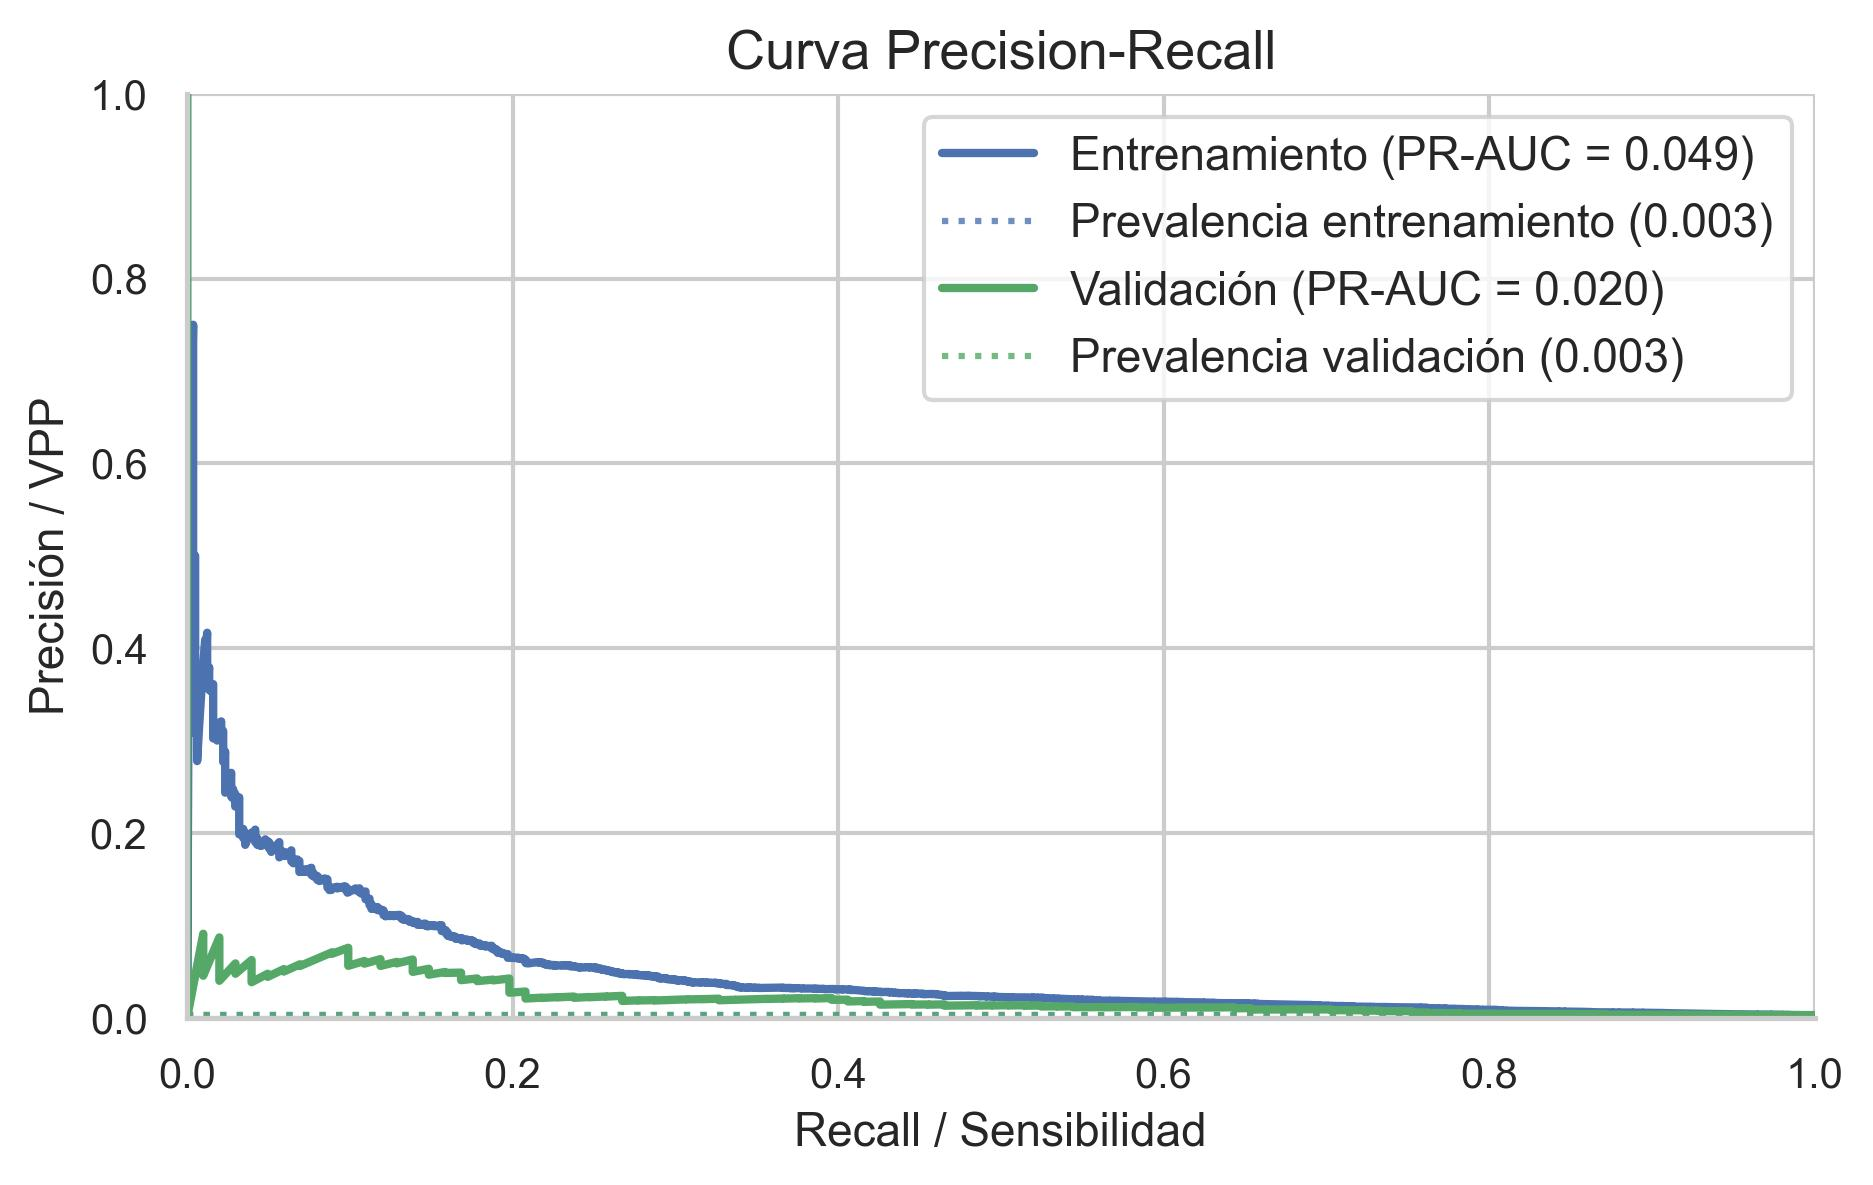

### Roc Curve

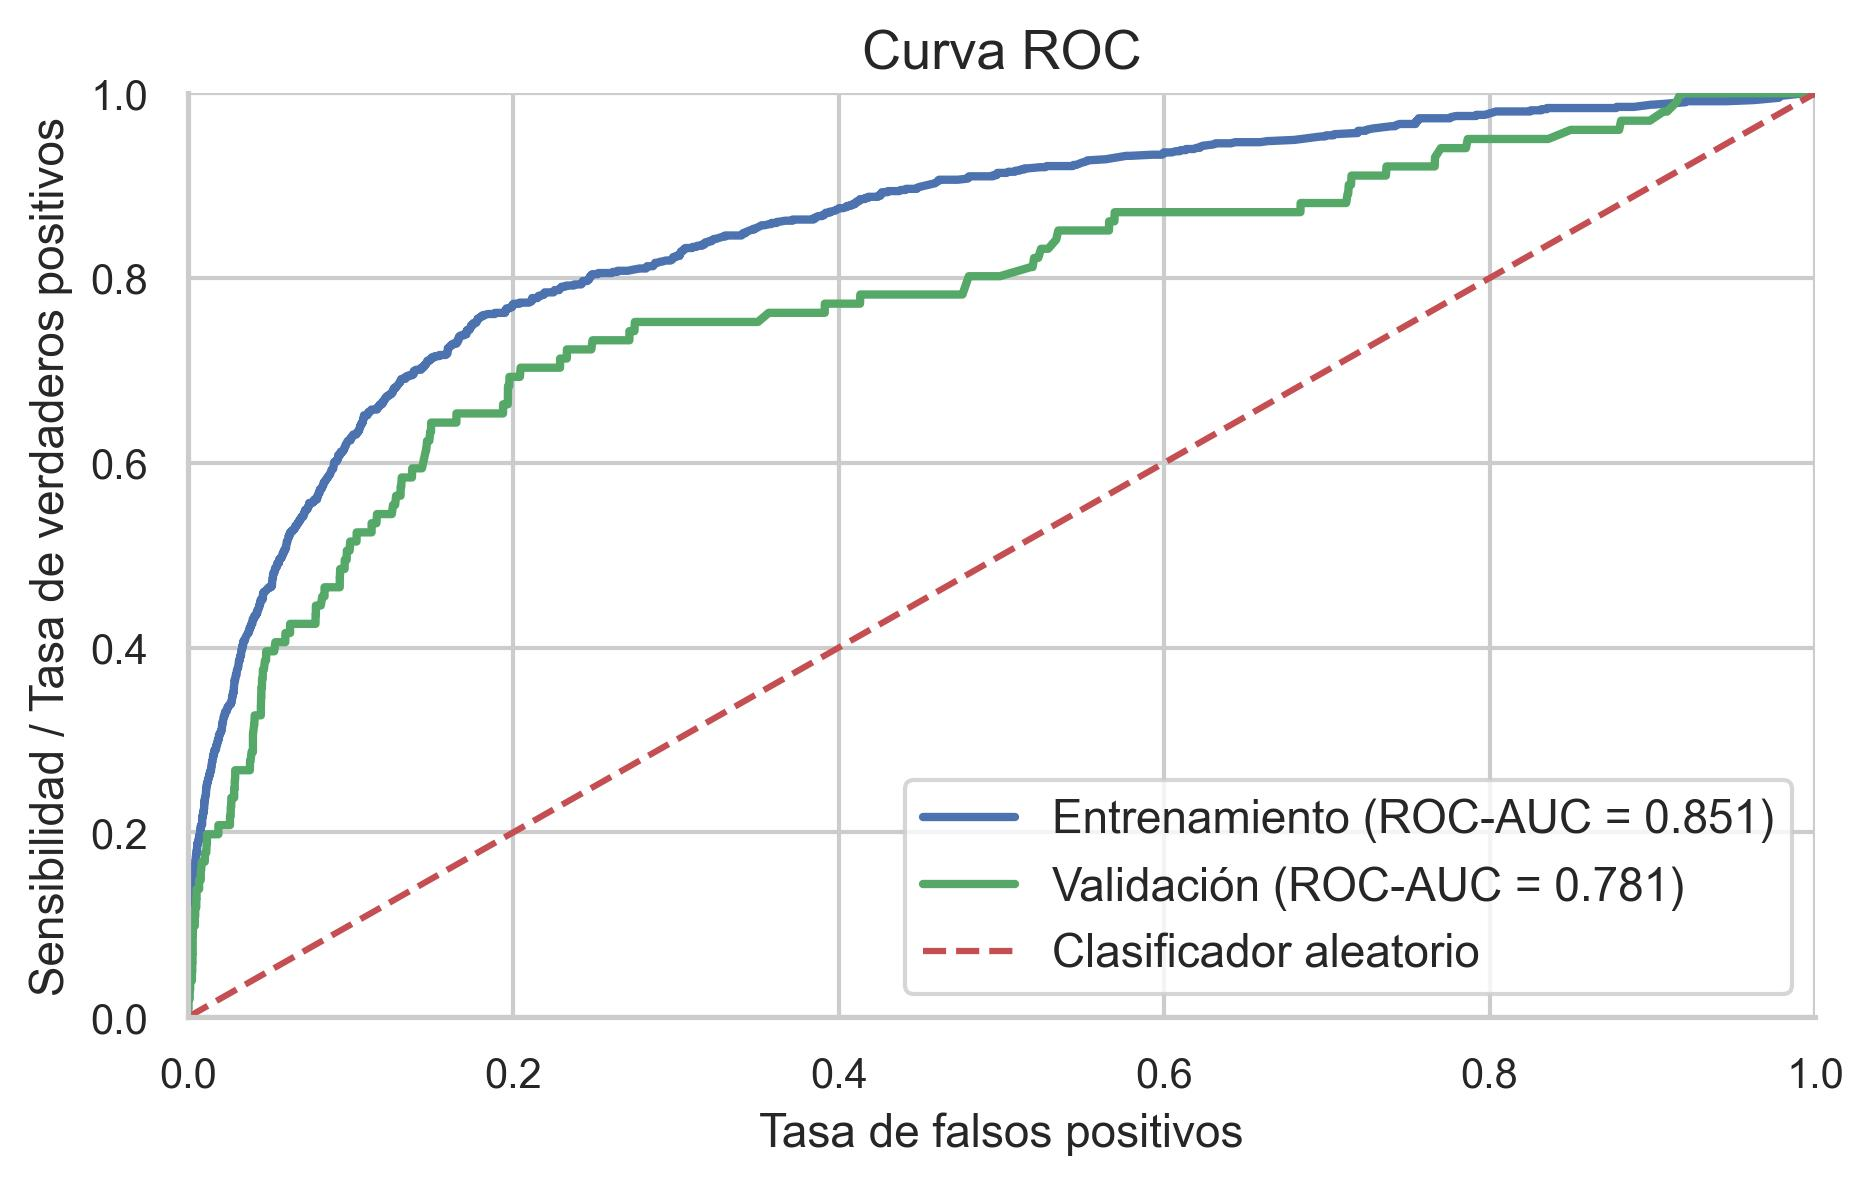

### Pr Roc Curves

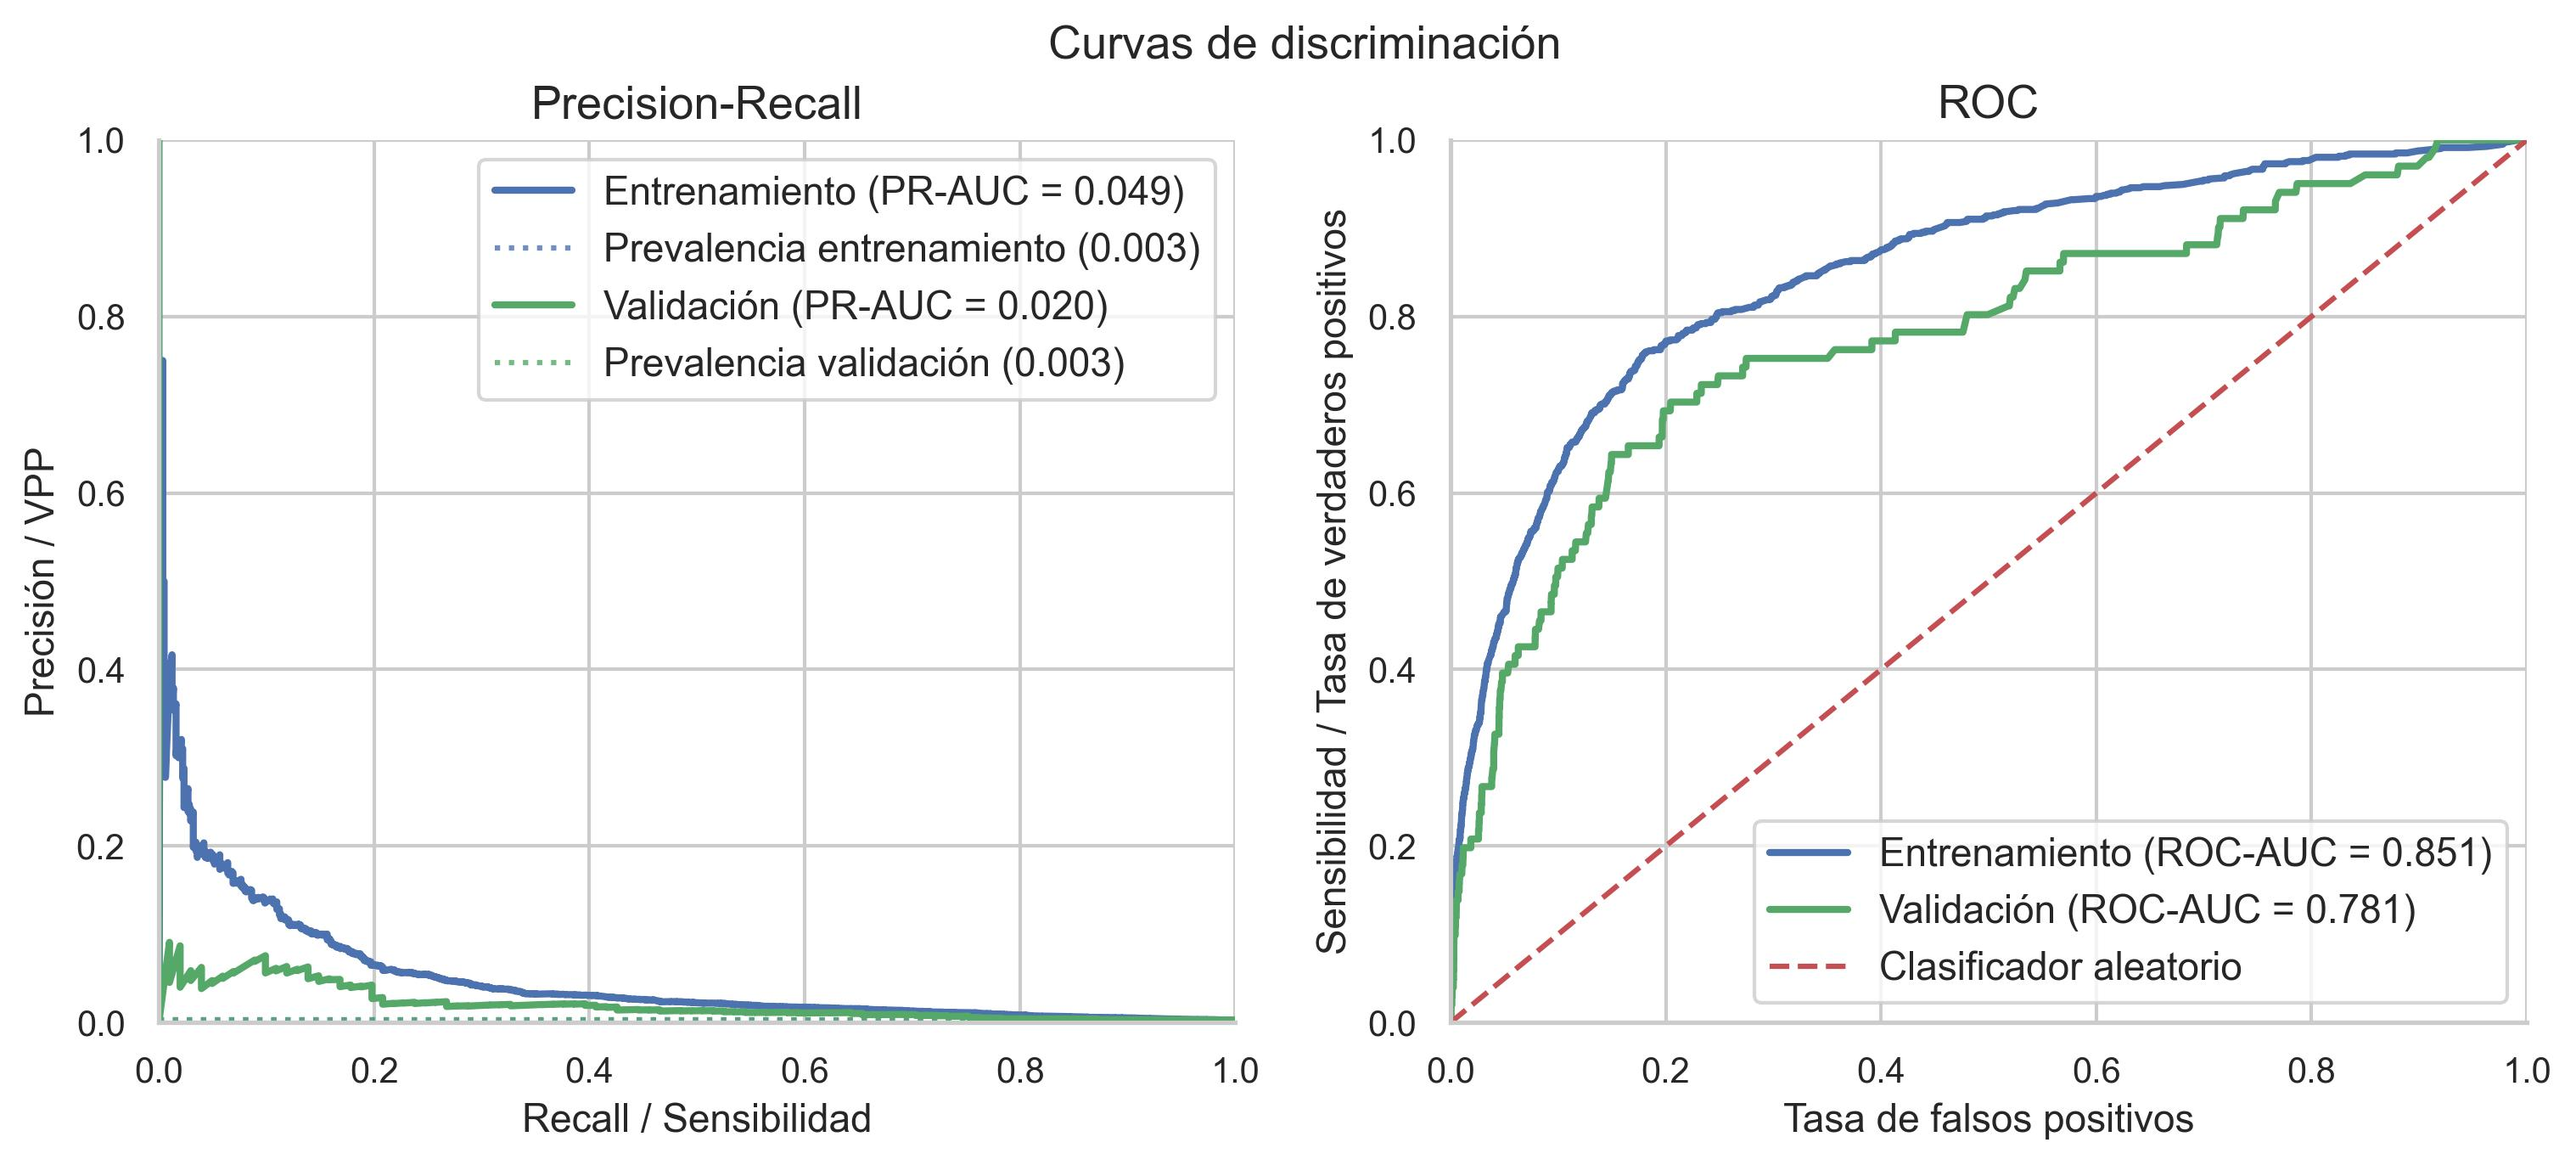

### Clinical Summary

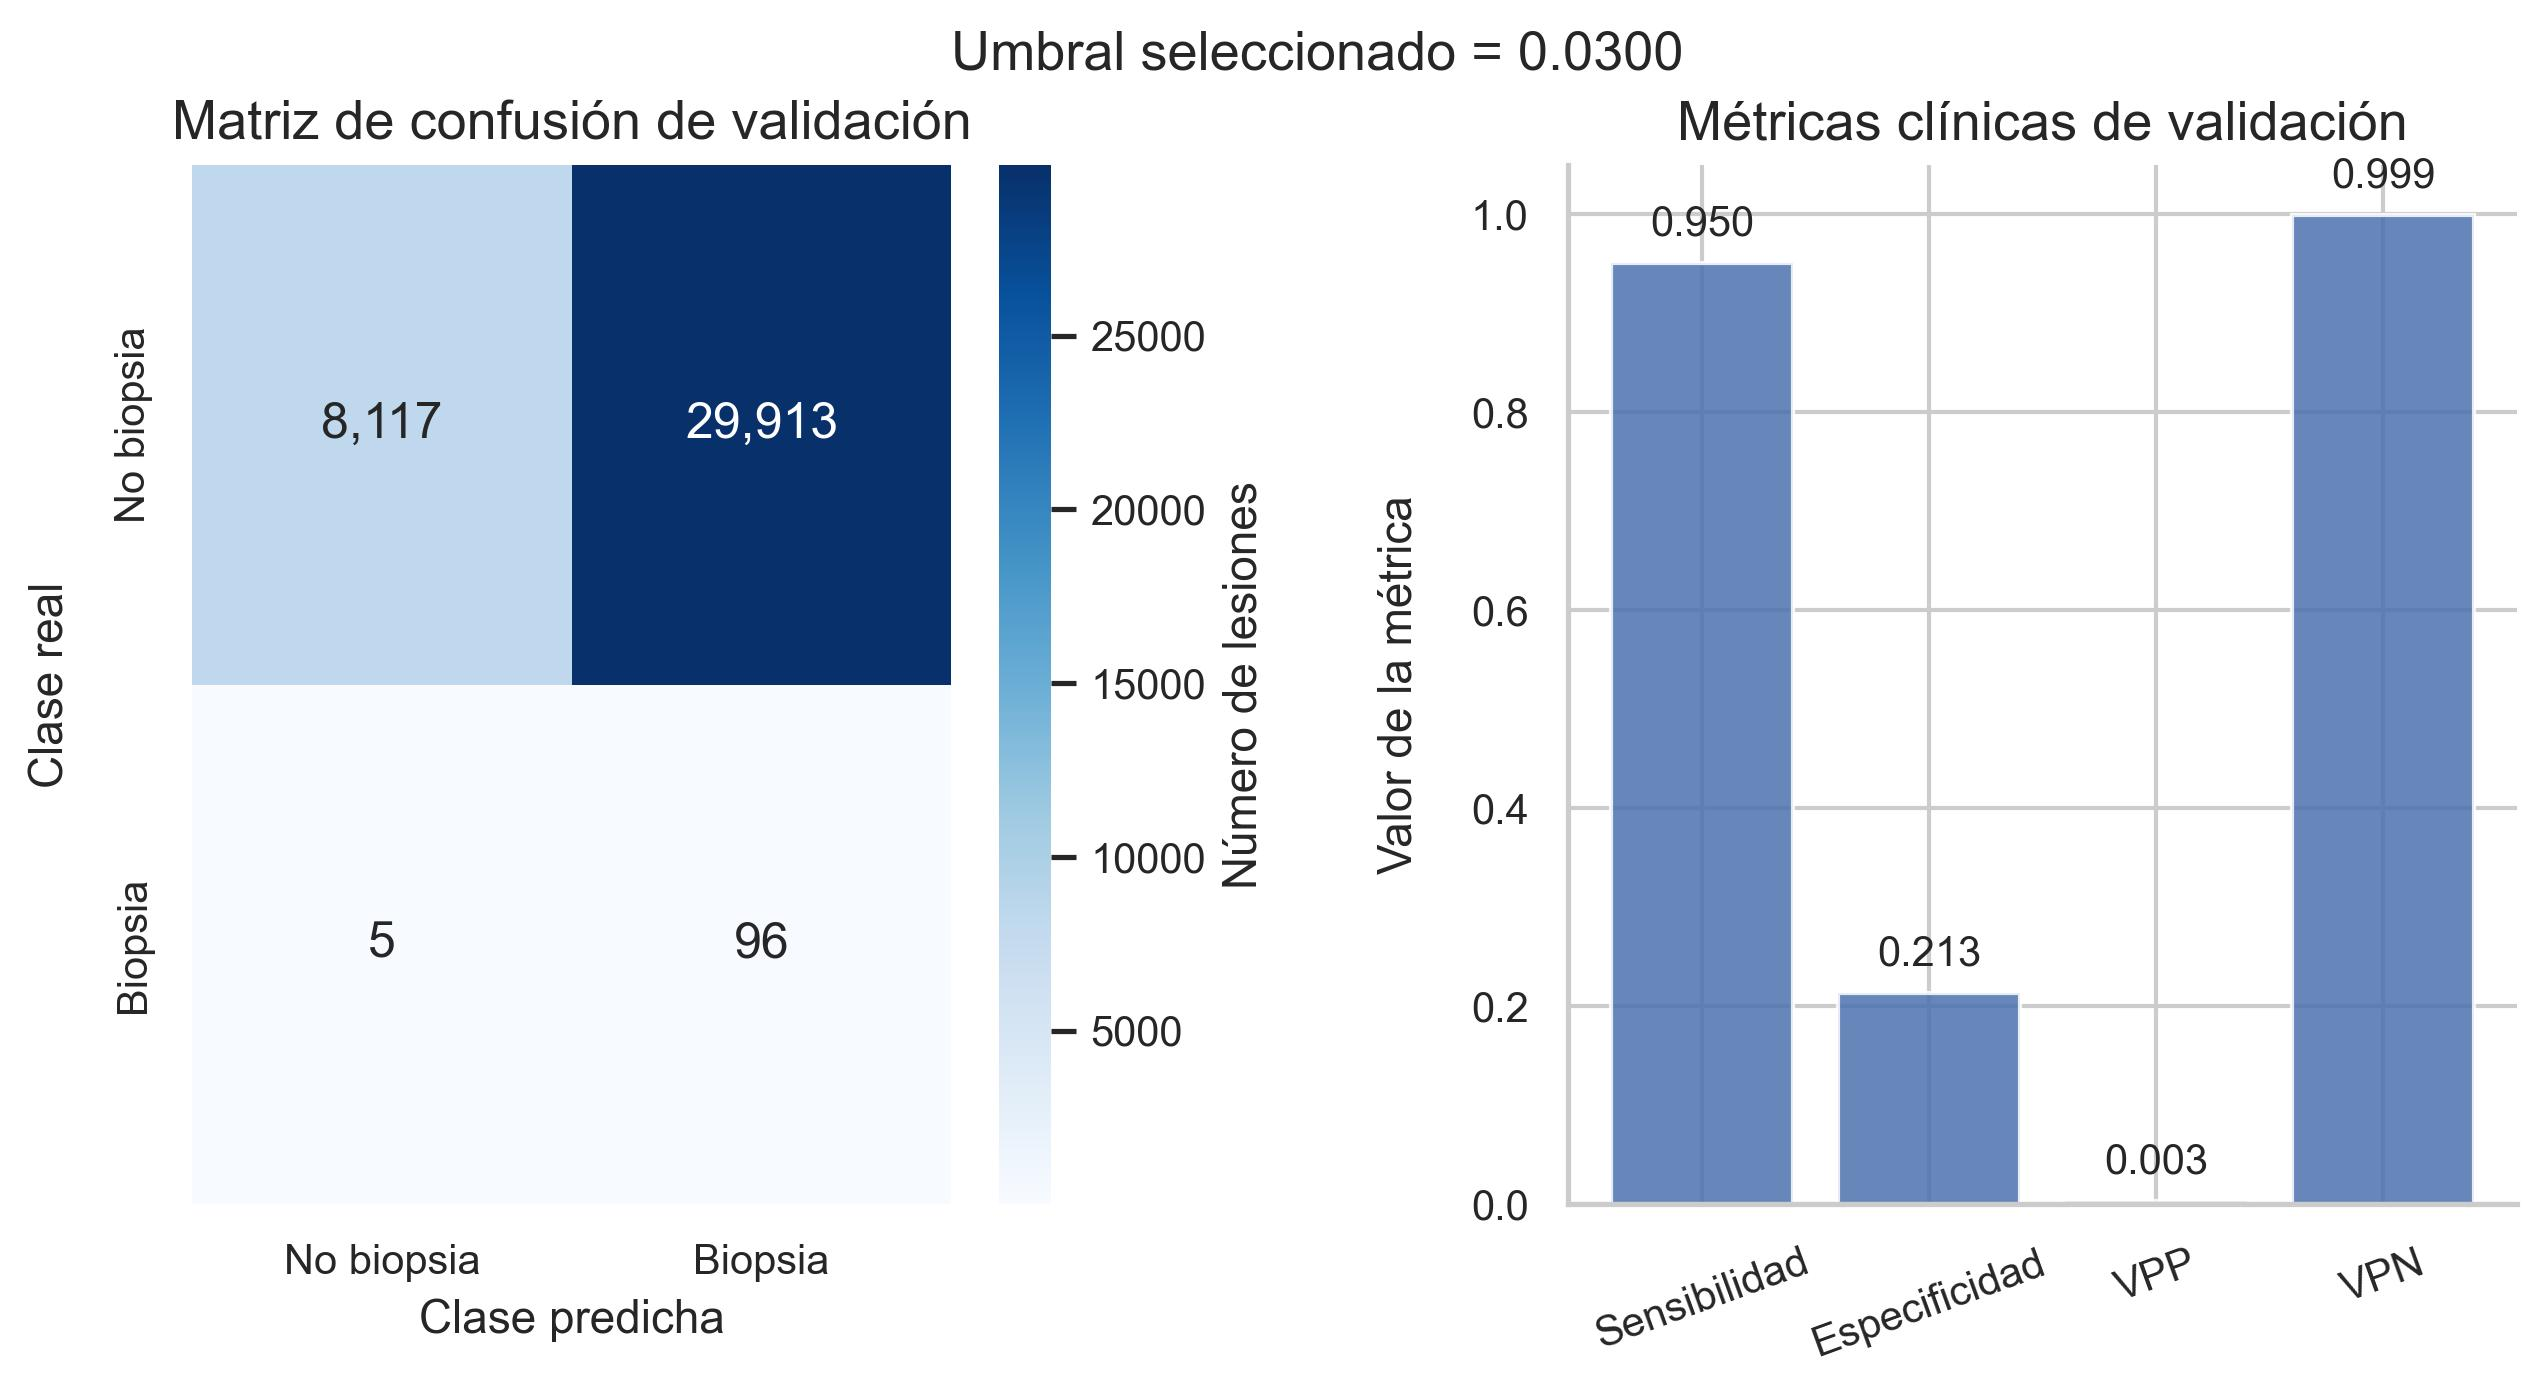

In [21]:
from IPython.display import Image, Markdown, display

for figure_name, figure_path in results["figure_paths"].items():
    display(Markdown(f"### {figure_name.replace('_', ' ').title()}"))
    display(Image(filename=str(figure_path)))